# 📊 Derivable Judgement 
#####         **(Health Dataset Statistical Analysis Project)**

## 📌 Project Description

This project demonstrates the application of **inferential statistics** using a simulated health dataset. It combines statistical theory with Python-based data analysis to explore relationships between health indicators such as age, BMI, smoking habits, and disease prevalence. The project showcases how statistical testing supports data-driven decision-making.

---

## 🎯 Project Objectives

- Apply inferential statistical concepts to real-world-style data  
- Formulate and test research hypotheses  
- Estimate population parameters using confidence intervals  
- Compare group means using statistical tests  
- Analyze categorical relationships  
- Study correlations between continuous variables  
- Interpret statistical results correctly  

---

## 🚀 Project Goals

- Bridge statistical theory with practical Python implementation  
- Develop analytical thinking and hypothesis testing skills  
- Understand decision-making using p-values and critical values  
- Gain hands-on experience with statistical tools  
- Build a strong foundation in data analysis  
- Create an academic-ready statistical project  

---

# Task : 1
#### Formulate at least two hypotheses from the dataset. 
**Example:**
- Ho: Smoking has no effect on Diabetes prevalence.
- H1: Smoking affects Diabetes prevalence.


In [1]:
import pandas as pd
import numpy as np
# Load dataset
file_path = "health_dataset.csv"
df = pd.read_csv(file_path)
# print(df.columns)
df


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,52277f36-ef67-46f7-9288-c434edce0e0b,18-25,18,80,Male,West,Smoker,Daily,31.33,104.1,True,False,154.3,166.3,13-07-2023
1,b785d681-e2b1-4177-9e69-68e3d8996027,18-25,21,74,Female,South,Non-Smoker,Rarely,25.54,96.7,True,False,167.8,154.5,13-07-2023
2,dbd0bfa9-9209-47a9-8560-796ff7957980,18-25,20,99,Female,North,Non-Smoker,Rarely,36.98,105.1,False,False,274.0,113.8,05-04-2022
3,336c699b-a923-49f7-85b8-df0d7d79f6c1,60+,69,50,Female,East,Former Smoker,Weekly,15.57,129.9,False,False,276.2,119.2,20-07-2023
4,5a4a0715-7c21-4755-ab85-accad695ef5a,18-25,18,74,Female,West,Former Smoker,Rarely,22.61,159.0,True,True,259.7,182.6,25-01-2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,134898ba-e23c-473a-bfa1-d88853e2aed1,18-25,25,68,Other,South,Smoker,Daily,26.46,146.1,True,True,176.3,134.3,21-08-2022
996,c62fccc2-24db-48bd-a5ee-8b0e8d628320,26-35,27,49,Other,South,Smoker,Rarely,19.79,127.9,False,False,201.6,111.3,21-07-2023
997,58360698-d5de-454d-a616-dcba0328a852,36-45,36,90,Female,North,Former Smoker,Daily,30.56,97.9,False,False,172.9,84.2,04-06-2023
998,862b2ddf-d546-4e68-a1dd-8c26fd55a3b6,26-35,29,86,Female,South,Smoker,Rarely,28.80,148.9,False,True,235.3,79.3,13-03-2023


In [2]:
smoking_diabetes = pd.crosstab(df["smoking_status"], df["diabetes"]) 
smoking_diabetes

diabetes,False,True
smoking_status,,
Former Smoker,148,183
Non-Smoker,135,193
Smoker,137,204


In [3]:
exercise_hypertension = pd.crosstab(df["exercise_frequency"], df["hypertension"])
exercise_hypertension

hypertension,False,True
exercise_frequency,,
Daily,134,130
Never,137,137
Rarely,125,116
Weekly,115,106


# Task : 2 
#### Calculate Confidence Intervals for key numerical data like age, weight, etc.

In [4]:
from scipy import stats

print("=== Task 2: 95% Confidence Intervals ===\n")
def confidence_interval(series, confidence=0.95):
    n = len(series)
    mean = np.mean(series)
    std = np.std(series, ddof=1) 
    t_critical = stats.t.ppf((1 + confidence) / 2, n - 1)
    margin_error = t_critical * (std / np.sqrt(n))
    
    lower = mean - margin_error
    upper = mean + margin_error
    
    return mean, lower, upper

columns = ["age", "weight", "bmi", "blood_pressure"]
for col in columns:
    mean, low, high = confidence_interval(df[col])
    
    print(f"{col.upper()}")
    print(f"Mean = {mean:.2f}")
    print(f"95% Confidence Interval = ({low:.2f}, {high:.2f})")
    print("-" * 40)


=== Task 2: 95% Confidence Intervals ===

AGE
Mean = 43.29
95% Confidence Interval = (42.13, 44.44)
----------------------------------------
WEIGHT
Mean = 82.41
95% Confidence Interval = (81.06, 83.77)
----------------------------------------
BMI
Mean = 28.95
95% Confidence Interval = (28.41, 29.49)
----------------------------------------
BLOOD_PRESSURE
Mean = 128.70
95% Confidence Interval = (127.56, 129.83)
----------------------------------------


# Task : 3
#### Find the Critical Value and p-value to interpret the test results.

In [15]:
print("=== Hypothesis Test (Mean Age) ===")
mu0 = 40
alpha = 0.05
print("H0: mean age = 40")
print("H1: mean age ≠ 40")

sample = df["age"] 

n = len(sample) 
mean = np.mean(sample) 
std = np.std(sample, ddof=1) 

t_stat = (mean - mu0) / (std / np.sqrt(n))

t_crit = stats.t.ppf(1 - alpha/2, n-1)

p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-1))

margin = t_crit * (std / np.sqrt(n))
ci_low = mean - margin
ci_high = mean + margin

print("\nSample mean:", round(mean,2))
print("t-statistic:", round(t_stat,4))
print("critical value:", round(t_crit,4))
print("p-value:", round(p_value,6))

print("\n95% Confidence Interval:", (round(ci_low,2), round(ci_high,2)))
if abs(t_stat) > t_crit:
    print("\nDecision: Reject H0")
else:
    print("\nDecision: Fail to Reject H0")

if mu0 < ci_low or mu0 > ci_high:
    print("CI conclusion: Reject H0")
else:
    print("CI conclusion: Fail to Reject H0")



=== Hypothesis Test (Mean Age) ===
H0: mean age = 40
H1: mean age ≠ 40

Sample mean: 43.29
t-statistic: 5.5864
critical value: 1.9623
p-value: 0.0

95% Confidence Interval: (np.float64(42.13), np.float64(44.44))

Decision: Reject H0
CI conclusion: Reject H0


### Conclusion

At the 5% significance level:

* If H₀ is rejected:
  **There is sufficient evidence to conclude that the population mean age is different from 40.**


# Task : 4
#### Perform z-test or t-test based on sample size (mean comparison across groups).


In [6]:
print("=== Task 4: Independent t-test (BMI: Male vs Female) ===\n")

male_bmi = df[df["gender"] == "Male"]["bmi"]
female_bmi = df[df["gender"] == "Female"]["bmi"]
mean_m = np.mean(male_bmi)
mean_f = np.mean(female_bmi)

t_stat, p_value = stats.ttest_ind(male_bmi, female_bmi, equal_var=False)

alpha = 0.05

print(f"Male BMI mean = {mean_m:.2f}")
print(f"Female BMI mean = {mean_f:.2f}")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")

print("\nDecision:")
if p_value < alpha:
    print("Reject H0 (BMI differs significantly between genders)")
else : 
    print("Fail to Reject H0")

=== Task 4: Independent t-test (BMI: Male vs Female) ===

Male BMI mean = 29.24
Female BMI mean = 28.53
t-statistic = 1.0513
p-value = 0.293510

Decision:
Fail to Reject H0


### Conclusion

At the 5% significance level:
* If p-value ≥ 0.05:
  **There is insufficient evidence to conclude that male and female mean BMI are different.**


# Task : 5
#### Conduct a chi-square test on categorical data (e.g., Smoking habit vs Disease).


In [7]:
from scipy.stats import chi2_contingency

print("=== Task 5: Chi-square Test (Smoking vs Diabetes) ===\n")
print("H0: Smoking status and diabetes are independent")
print("H1: Smoking status and diabetes are associated\n")

table = pd.crosstab(df["smoking_status"], df["diabetes"])
print("Contingency Table:\n")
print(table)
print()

chi2_stat, p_value, dof, expected = chi2_contingency(table)

alpha = 0.05

print(f"Chi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p_value:.6f}\n")

print("Decision:")
if p_value < alpha:
    print("Reject H0 (Smoking and diabetes are associated)")
else:
    print("Fail to Reject H0 (No significant association)")


=== Task 5: Chi-square Test (Smoking vs Diabetes) ===

H0: Smoking status and diabetes are independent
H1: Smoking status and diabetes are associated

Contingency Table:

diabetes        False  True 
smoking_status              
Former Smoker     148    183
Non-Smoker        135    193
Smoker            137    204

Chi-square statistic = 1.5612
Degrees of freedom = 2
p-value = 0.458133

Decision:
Fail to Reject H0 (No significant association)


### Conclusion : 
At the 5% significance level:

* If p-value ≥ 0.05:
  **There is insufficient evidence to conclude that smoking status and diabetes are associated.**

# Task : 6
#### Perform an ANOVA test to check if age groups significantly differ in disease rate.


In [8]:
from scipy.stats import f_oneway

print("=== ANOVA Test: Age Group vs Diabetes Rate ===\n")
print("H0: μ1 = μ2 = μ3 = ... = μk")
print("H1: At least one mean is different (∃ i ≠ j such that μi ≠ μj)")

# Convert boolean diabetes to numeric (True=1, False=0)
df["diabetes_numeric"] = df["diabetes"].astype(int)

groups = []
labels = df["age_group"].unique()

for label in labels:
    group_data = df[df["age_group"] == label]["diabetes_numeric"]
    groups.append(group_data)

# ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))

alpha = 0.05
print("\nDecision:")
if p_value < alpha:
    print("Reject H0 → Disease rate differs across age groups")
else:
    print("Fail to Reject H0 → No significant difference")

=== ANOVA Test: Age Group vs Diabetes Rate ===

H0: μ1 = μ2 = μ3 = ... = μk
H1: At least one mean is different (∃ i ≠ j such that μi ≠ μj)
F-statistic: 1.3987
p-value: 0.232395

Decision:
Fail to Reject H0 → No significant difference


### Conclusion
At the 5% significance level:
* If p-value ≥ 0.05:
  **There is insufficient evidence to conclude that diabetes rates differ across age groups.**


# Task : 7
#### Calculate Covariance and Correlation between continuous variables (e.g., Age vs. BMI)

In [9]:
print("=== Covariance & Correlation: Age vs BMI ===\n")

age = df["age"]
bmi = df["bmi"]

covariance_matrix = np.cov(age, bmi)
covariance_value = covariance_matrix[0, 1]

correlation_value = np.corrcoef(age, bmi)[0, 1]

print("Covariance (Age, BMI):", round(covariance_value, 4))
print("Correlation (Age, BMI):", round(correlation_value, 4))

# Interpretation
print("\nInterpretation:")
if correlation_value > 0:
    print("Positive relationship → BMI tends to increase with age.")
elif correlation_value < 0:
    print("Negative relationship → BMI tends to decrease with age.")
else:
    print("No linear relationship detected.")


=== Covariance & Correlation: Age vs BMI ===

Covariance (Age, BMI): -1.4807
Correlation (Age, BMI): -0.0091

Interpretation:
Negative relationship → BMI tends to decrease with age.


### Conclusion

* If correlation > 0:
  **Age and BMI show a positive relationship — BMI tends to increase with age.**

* If correlation < 0:
  **Age and BMI show a negative relationship — BMI tends to decrease with age.**

* If correlation ≈ 0:
  **There is no meaningful linear relationship between age and BMI.**


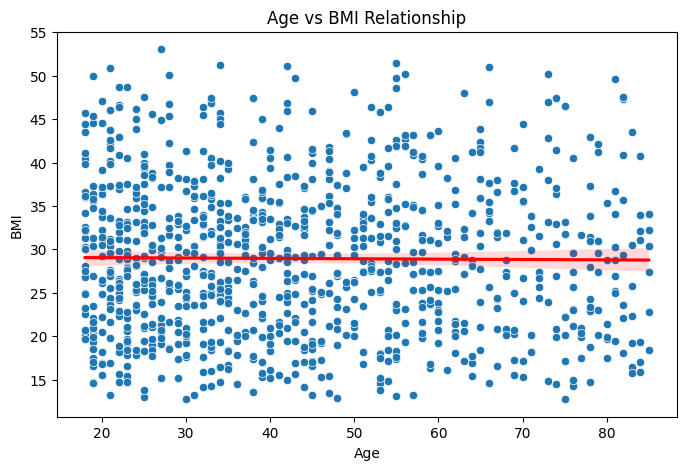

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(8,5))

sns.scatterplot(x=age, y=bmi)
sns.regplot(x=age, y=bmi, scatter=False, color="red")  # regression line

plt.title("Age vs BMI Relationship")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.show()